In this wrap-up quiz you will need to write some code in order to answer the quiz questions. 

Open the dataset `ames_housing_no_missing.csv` with the following command:

In [11]:
import pandas as pd
ames_housing = pd.read_csv("../datasets/ames_housing_no_missing.csv")

target_name = "SalePrice"
data, target = ames_housing.drop(columns=target_name), ames_housing[target_name]

target = (target > 200_000).astype(int)

`ames_housing` is a pandas dataframe. The column "SalePrice" contains the target variable.

We did not encounter any regression problem yet. Therefore, we convert the regression target into a classification target to predict whether or not an house is expensive. "Expensive" is defined as a sale price greater than $200,000.

### Question 1

Use the `data.info()` and `data.head()` commands to examine the columns of the dataframe. The dataset contains:

- **a)** only numerical features
- **b)** only categorical features
- **c)** both numerical and categorical features :white_check_mark:

To answer to the question, you can check the dataframe information with the following command:

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

and

In [13]:
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,0,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,0,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,0,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal


### Question 2

How many features are available to predict whether or not a house is expensive ? 

- **a)** 79
- **b)** 80
- **c)** 81

From the original dataframe, we should exclude the column "SalePrice" because it corresponds to the target that we want to predict.

In [18]:
# print(f"The dataset is composed of {data.shape[1]} features")
len(data.columns)

79

The resulting dataframe named "data" has 79 columns as seen with the `data.shape` attribute or by measuring `len(data.columns)` for instance. 

### Question 3

How many features are represented with numbers? 

- **a)** 0
- **b)** 36
- **c)** 42
- **d)** 79 

**Hint:** You can use the method `df.select_dtypes` or the function `sklearn.compose.make_column_selector`
as shown in the notebook.

In [23]:
data.dtypes.value_counts()

str        43
int64      33
float64     3
Name: count, dtype: int64

You can only select columns corresponding to data type `int64` and `float64`. The following code will filter these columns:

In [24]:
data_numbers = data.select_dtypes(["integer", "float"])
data_numbers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   LotFrontage    1460 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   OverallQual    1460 non-null   int64  
 4   OverallCond    1460 non-null   int64  
 5   YearBuilt      1460 non-null   int64  
 6   YearRemodAdd   1460 non-null   int64  
 7   MasVnrArea     1460 non-null   float64
 8   BsmtFinSF1     1460 non-null   int64  
 9   BsmtFinSF2     1460 non-null   int64  
 10  BsmtUnfSF      1460 non-null   int64  
 11  TotalBsmtSF    1460 non-null   int64  
 12  1stFlrSF       1460 non-null   int64  
 13  2ndFlrSF       1460 non-null   int64  
 14  LowQualFinSF   1460 non-null   int64  
 15  GrLivArea      1460 non-null   int64  
 16  BsmtFullBath   1460 non-null   int64  
 17  BsmtHalfBath   1460 non-null   int64  
 18  FullBath       1460

In this case, 36 columns will be available. Programmatically, we can also access the number of columns with:

In [25]:
len(data_numbers.columns)

36

### Question 4

Refer to the **dataset description** regarding the meaning of the dataset.

Among the following columns, which columns express a quantitative numerical value (excluding ordinal categories)? 
- **a)** "LotFrontage"
- **b)** "LotArea"
- **c)** "OverallQual"
- **d)** "OverallCond"
- **e)** "YearBuilt"

Select all answers that apply

Explanation

Solution: a) b) e)

"OverallQual" and "OverallCond" are ordinal categorical variables. While technically "YearBuilt" is more a date than a quantity, it is fine for machine learning models to treat it as a quantity because the year of construction is directly related to the age of the house.

We consider the following numerical columns:

In [40]:
numerical_features = [
  "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
  "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
  "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
  "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
  "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]

### Question 5

Now create a predictive model that uses these numerical columns as input data. Your predictive model should be a pipeline composed of a `sklearn.preprocessing.StandardScaler` to scale these numerical data and a `sklearn.linear_model.LogisticRegression`.``

What is the accuracy score obtained by 10-fold cross-validation (you can set the parameter cv=10 when calling `cross_validate`) of this pipeline?
- **a)** ~0.5
- **b)** ~0.7
- **c)** ~0.9

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

# 1. Select only numerical columns:
data_numerical = data[numerical_features]

# 2. Build the pipline:
model = make_pipeline(StandardScaler(), LogisticRegression())

# 3. Perform 10-fold Cross-validation:
cv_results_num = cross_validate(model, data_numerical, target, cv=10) 

# 4. Compute mean accuracy score:
test_score_num = cv_results_num["test_score"]
test_score_num.mean()
#print(f"The accuracy score for 10-fold cross-validation is {test_score_num:.3f}")

np.float64(0.8924657534246576)

### Question 6

Instead of solely using the numerical columns, let us build a pipeline that can process both the numerical and categorical features together as follows:

- the `numerical_features` (as defined above) should be processed as previously done with a `StandardScaler`;
- the left-out columns should be treated as categorical variables using a `sklearn.preprocessing.OneHotEncoder`. To avoid any issue with rare categories that could only be present during the prediction, you can pass the parameter `handle_unknown="ignore"` to the `OneHotEncoder`.

What is the accuracy score obtained by 10-fold cross-validation of the pipeline using both the numerical and categorical features? 
- **a)** ~0.7
- **b)** ~0.9
- **c)** ~1.0

In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

# 1. Identify remaining categorical features:
categorical_features = [col for col in data.columns if col not in numerical_features]

# 2. Create a columnTransformer to process the numerical and categorical features:
preprocessor = ColumnTransformer(

    transformers=[
        ("num", StandardScaler(), numerical_features),
         ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# 3. Combine the preprocessor and mode into a the pipline:
model = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))

# 4. Perform 10-fold Cross-validation:
cv_results_all = cross_validate(model, data, target, cv=10) 

# 5. Compute mean accuracy score:
test_score_all = cv_results_all["test_score"]
test_score_all.mean()
#print(f"The accuracy score for 10-fold cross-validation is {test_score_all:.3f}")

np.float64(0.9164383561643834)

From this analysis, we observe that the mean test score of the model taking into account both numerical and categorical features is higher than only using the numerical features.

### Question 7

One way to compare two models is by comparing their means, but small differences in performance measures might easily turn out to be merely by chance (e.g. when using random resampling during cross-validation), and not because one model predicts systematically better than the other.

Another way is to compare cross-validation test scores of both models fold-to-fold, i.e. counting the number of folds where one model has a better test score than the other. This provides some extra information: are some partitions of the data making the classification task particularly easy or hard for both models?

Let's visualize the second approach.

![Cross-validation test scores](../figures/CrossValidationTestScores.png)

Compare both models by counting on how many folds the model using all features has a better test score than the other.

Select the correct statement:
- **a)** [0, 3]: the model using all features is consistently worse 
- **b)** [4, 6]: both models are almost equivalent 
- **c)** [7, 10]: the model using all features is consistently better 

To answer the question, we can now compare the score of each fold to investigate if this improvement is generally happening on all folds of the cross-validation:

A using all features is better than amodel using only numerical features for 9 CV iterations out of 10


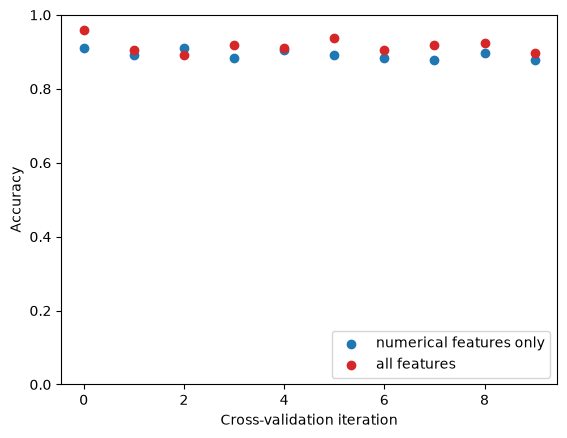

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Plot comparaison fold-by-fold
indices = np.arange(len(test_score_num))
plt.scatter(
    indices, test_score_num, color="tab:blue", label="numerical features only"
)
plt.scatter(
    indices, test_score_all, color="tab:red", label="all features"
)
plt.ylim(0, 1)
plt.xlabel("Cross-validation iteration")
plt.ylabel("Accuracy")
_=plt.legend(loc="lower right")

print(
    "A using all features is better than a"
    "model using only numerical features for"
    f" {sum(test_score_all > test_score_num)} CV iterations out of 10"
    )

In [ ]:
# Count how many times the model use all features has a better test score than the other.
better_folds = (score_all > score_num).sum()

print(f"The model with all features performed better in {better_folds} out of 10 folds")